# Wireless Coverage — Part 4: Naive Tower Siting via H3 Viewsheds

> **Docs:** [Wireless Coverage — notebook series](https://databrickslabs.github.io/geobrix/docs/notebooks/wireless-coverage?flavor=notebooks)

> **Next — [Coming Soon]:** a `land_cover` notebook weights coverage by demand (people/buildings), excludes water/park/no-build, and optimizes the best spot within each cell — turning this baseline into a smarter siting tool.

![Wireless Coverage Part 4 — naive H3-native tower siting pipeline](https://raw.githubusercontent.com/databrickslabs/geobrix/main/resources/images/diagrams/wireless-coverage/wireless-coverage-04.png)

With the LiDAR surfaces from Part 2a (or Part 2b) in hand, this notebook asks the siting question:
*which candidate tower locations are worth it?* We go **beyond pixels** — the viewshed is a line-of-sight
search over **H3 cells as pixels** (bin the surface to a max height per cell at a chosen resolution;
the H3 resolution is the only "shortcut", the line-of-sight itself is exact).

This is the **naive** baseline — one candidate tower per H3 cell centroid, surface-level line-of-sight,
no land cover. Each site is scored on **two factors**: the **mast height it needs** (to clear the local
surface — low is cheaper) and the **viewshed it achieves** (coverage — high is better). A cheap
**quick-pass rules most sites out** before any detailed work; survivors get the full viewshed.

> **Next in the series.** A `land_cover` notebook adds the *demand* side (weight coverage by where
> people/buildings are, exclude water/park), and best-spot-within-cell placement — turning this naive
> screen into a smarter siting tool.

> **Runtime.** Databricks Serverless environment 6 — the [lightweight tier](https://databrickslabs.github.io/geobrix/docs/api/execution-tiers) (pure Python/PySpark + `h3`, no JAR). `DEMO=True` runs a Golden Gate Park sub-AOI; at full scale the per-tower viewshed is a one-tower-per-task (or Lakeflow) run.

---
**Last Update:** 2026-10-05

In [ ]:
%pip install --quiet --disable-pip-version-check --no-deps --force-reinstall "geobrix @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.5.2-py3-none-any.whl"
%pip install --quiet "geobrix[light_env6,vizx] @ file:///Volumes/geospatial_docs/geobrix/sample-data/geobrix-0.5.2-py3-none-any.whl"

In [ ]:
%restart_python

In [0]:
%run ./config_nb

AOI EPSG:3857: x=[-13642204, -13619940] y=[4537132, 4558257]
Tile: 1024 m = 1024 px | H3_RESOLUTION = 10


In [0]:
# ── nb4 overrides (after %run ./config_nb) ──────────────────────────────────
# config_nb provides: F, DBF, rx, _tbl, _persist, _points_as_gdf, plot_static, vector_layer,
#   cells_as_gdf, lonlat_to_3857, glob, X0, Y0, TILE_M, SF_AOI, CATALOG, SCHEMA.
import h3, time
from databricks.labs.gbx.pygx import h3_los_visible   # H3 line-of-sight, promoted to the library

DEMO            = True
FORCE_RELOAD    = False       # True → rebuild the H3 surface bin + output tables
OUT_PREFIX      = "wc_h3"

MAX_DIST_M      = 2500.0      # 5G urban coverage buffer
SURFACE_BIN_RES        = 13          # finest H3 bin (surface "pixel"); pyramid downsamples from here
VIEWSHED_RES        = 12          # detailed viewshed resolution (survivors)
QUICKPASS_RES       = 10          # coarse quick-pass resolution (cheap rule-out)
TOWER_RES       = 9           # naive candidate lattice: one tower per H3 cell centroid
ANTENNA_ABOVE_SURFACE_M = 10.0   # antenna sits this far above the local surface (DSM)
TARGET_H        = 1.6         # receiver this far above the surface at the target
QUICK_THRESH_FRAC = 0.30      # survive the quick pass if coarse viewshed fraction >= this (rules out ~2/3)
GROUND_FILL_K   = 3           # required_mast: nearest-ground fallback searches this many H3 rings

GGP_LON, GGP_LAT = -122.486, 37.769   # demo-area center
WIN_TILES       = 5           # bin surfaces +/- this many 1024m tiles (covers towers + buffers)
TOWER_WIN_TILES = 2           # candidate lattice spans +/- this many tiles around center


def _nearest_ground(cell, gmap, k_max):
    """Nearest MEASURED bare-earth for a tower cell with no DTM value: expand H3 rings and return
    the mean ground of the nearest populated ring. None only when no ground lies within k_max rings
    (genuine no-data, e.g. open water) -- never fabricated."""
    for k in range(1, k_max + 1):
        vals = [gmap[c] for c in h3.grid_disk(cell, k) if gmap.get(c) is not None]
        if vals:
            return sum(vals) / len(vals)
    return None


def tower_viewshed(tla, tlo, res, surf_map, cxy, max_dist, grnd_map=None):
    """One tower's exact surface-relative viewshed at `res`. observer = DSM@tower + antenna clearance;
    targets = cells within max_dist. Returns stats (+ required_mast = CHM@tower + clearance when
    grnd_map given), or None if the tower sits on NoData surface."""
    tw = lonlat_to_3857(tlo, tla)
    tcell = h3.latlng_to_cell(tla, tlo, res)
    st = surf_map.get(tcell)
    if st is None:
        return None
    obs_z = st + ANTENNA_ABOVE_SURFACE_M
    tw2 = (tw[0], tw[1])
    tgts = [c for c, (x, y) in cxy.items()
            if surf_map.get(c) is not None and (x - tw2[0])**2 + (y - tw2[1])**2 <= max_dist * max_dist]
    vis = h3_los_visible(tcell, obs_z, tgts, surf_map, surf_map, TARGET_H)  # surface-relative target
    out = {"tcell": tcell, "lat": tla, "lon": tlo, "tw": tw, "obs_z": obs_z,
           "n_targets": len(tgts), "n_visible": len(vis), "frac": len(vis) / max(len(tgts), 1),
           "visible": vis}
    if grnd_map is not None:
        g_exact = grnd_map.get(tcell)
        g = g_exact if g_exact is not None else _nearest_ground(tcell, grnd_map, GROUND_FILL_K)
        out["mast_exact"] = g_exact is not None
        out["required_mast"] = (st - g) + ANTENNA_ABOVE_SURFACE_M if g is not None else None
    return out


_CX, _CY = lonlat_to_3857(GGP_LON, GGP_LAT)
print(f"DEMO={DEMO} | buffer={MAX_DIST_M:.0f}m | bin res {SURFACE_BIN_RES} -> quick {QUICKPASS_RES}/fine {VIEWSHED_RES} | "
      f"antenna +{ANTENNA_ABOVE_SURFACE_M:.0f}m above surface")

DEMO=True | buffer=2500m | bin res 13 -> quick 10/fine 12 | antenna +10m above surface


## Bin the surfaces to H3 "pixels" and build the resolution pyramid

Bin the DSM (surface, **max** per cell) and DTM (ground, **min** per cell) to H3 at `SURFACE_BIN_RES` over the
area, then downsample to the quick/fine resolutions (surface = max-of-children, ground = min — exact,
since max/min are associative, so we read the raster only once). The surface heights are the viewshed's
blockers; the ground is used only to report each site's required mast (`CHM = DSM − DTM`).

Everything below is gated on `FORCE_RELOAD`: once the output tables exist, a re-run **loads them and
skips the per-tower viewsheds**. Set `FORCE_RELOAD=True` (or change a parameter) to recompute.

In [0]:
_rebuild = FORCE_RELOAD or not all(
    spark.catalog.tableExists(_tbl(OUT_PREFIX, _n, _r)) for _n, _r in
    [("quickpass", TOWER_RES), ("candidate_sites", TOWER_RES),
     ("coverage", VIEWSHED_RES), ("coverage_top10", VIEWSHED_RES)])
_DTX, _DTY = int((_CX - X0)//TILE_M), int((_CY - Y0)//TILE_M)
if not _rebuild:
    print("viewshed outputs already persisted -- loading tables (FORCE_RELOAD=True to recompute)")
else:
    # DEMO scopes the surface bin to a GGP window; full SF (DEMO=False) bins the whole AOI — heavy
    # (the per-tower pass is what a Lakeflow run parallelizes).
    _winf = ((F.col("tx").between(_DTX - WIN_TILES, _DTX + WIN_TILES) &
              F.col("ty").between(_DTY - WIN_TILES, _DTY + WIN_TILES)) if DEMO else F.lit(True))

    def _bin_h3(table, col, res, agg):
        # agg = "max" for the surface (DSM) blocker; "min" for the ground (DTM) base (bare earth).
        df = (spark.table(f"{CATALOG}.{SCHEMA}.{table}").where(_winf)
              .select("tx", "ty", rx.rst_transform(col, F.lit(4326)).alias("t4326")))
        df.createOrReplaceTempView("_nb4_binv")
        return spark.sql(
            f"SELECT t.cellID AS cell, {agg}(t.measure) AS z "
            f"FROM _nb4_binv, LATERAL gbx_rst_h3_rastertogrid{agg}(t4326, {res}) t "
            f"WHERE t.band = 1 GROUP BY t.cellID"
        )

    _t0 = time.time()
    surf_fine = _persist(_bin_h3("wc_surface_dsm", "dsm", SURFACE_BIN_RES, "max"), f"surf_r{SURFACE_BIN_RES}")
    grnd_fine = _persist(_bin_h3("wc_surface_dtm", "dtm", SURFACE_BIN_RES, "min"), f"grnd_r{SURFACE_BIN_RES}")

    def _collect(base, res, agg):
        df = (base if res == SURFACE_BIN_RES
              else base.groupBy(DBF.h3_toparent("cell", F.lit(res)).alias("cell")).agg(agg("z").alias("z")))
        m = {h3.int_to_str(r["cell"]): r["z"] for r in df.collect()}
        cxy = {}
        for c in m:
            la, lo = h3.cell_to_latlng(c)
            cxy[c] = lonlat_to_3857(lo, la)
        return m, cxy

    surf12, cxy12 = _collect(surf_fine, VIEWSHED_RES, F.max)
    grnd12, _ = _collect(grnd_fine, VIEWSHED_RES, F.min)
    surf10, cxy10 = _collect(surf_fine, QUICKPASS_RES, F.max)
    print(f"H3 pyramid ({time.time()-_t0:.0f}s): fine res {VIEWSHED_RES} {len(surf12):,} cells | "
          f"quick res {QUICKPASS_RES} {len(surf10):,} cells")

viewshed outputs already persisted -- loading tables (FORCE_RELOAD=True to recompute)


## Candidate towers — the naive centroid lattice

The naive placement: one candidate tower per H3 cell (`TOWER_RES`) over the area of interest. (A later
notebook can optimize the best spot *within* a cell; here we take the centroid.)

In [0]:
if _rebuild:
    from shapely.geometry import box as _box
    import pyproj
    _to4326 = pyproj.Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
    if DEMO:
        _tx0 = X0 + (_DTX - TOWER_WIN_TILES) * TILE_M
        _ty0 = Y0 + (_DTY - TOWER_WIN_TILES) * TILE_M
        _tx1 = X0 + (_DTX + TOWER_WIN_TILES + 1) * TILE_M
        _ty1 = Y0 + (_DTY + TOWER_WIN_TILES + 1) * TILE_M
        _w, _s = _to4326.transform(_tx0, _ty0)
        _e, _n = _to4326.transform(_tx1, _ty1)
    else:
        _w, _s, _e, _n = SF_AOI    # full San Francisco AOI
    _aoi_wkb = _box(_w, _s, _e, _n).wkb
    cand_cells = [r["cell"] for r in spark.createDataFrame([(1,)], "g int")
                  .select(F.explode(DBF.h3_try_coverash3(F.lit(_aoi_wkb), F.lit(TOWER_RES))).alias("cell"))
                  .where(F.col("cell").isNotNull()).collect()]
    cand_latlng = [h3.cell_to_latlng(h3.int_to_str(c)) for c in cand_cells]
    print(f"candidate towers (res {TOWER_RES}, +/-{TOWER_WIN_TILES} tiles): {len(cand_latlng)}")

## Quick pass — rule out weak sites cheaply (early exit)

For every candidate, a cheap **coarse-resolution** viewshed; if it can't clear `QUICK_THRESH_FRAC` of
its buffer, the site is **ruled out** (early exit) and never pays for the detailed viewshed. Most sites
die here.

In [0]:
if _rebuild:
    _t0 = time.time()
    _scored = []
    for (la, lo) in cand_latlng:
        qp = tower_viewshed(la, lo, QUICKPASS_RES, surf10, cxy10, MAX_DIST_M)
        if qp is not None:
            _scored.append((float(lo), float(la), round(qp["frac"], 4)))
    quick = _persist(spark.createDataFrame(_scored, "lon double, lat double, quick_frac double"),
                     "quickpass", res=TOWER_RES)
    print(f"quick pass scored {len(_scored)} candidates in {time.time()-_t0:.0f}s")
else:
    quick = spark.table(_tbl(OUT_PREFIX, "quickpass", TOWER_RES))
survivors = [(r["lat"], r["lon"]) for r in
             quick.where(F.col("quick_frac") >= F.lit(QUICK_THRESH_FRAC)).select("lat", "lon").collect()]
_n_cand = quick.count()
print(f"quick pass: {len(survivors)} survive, {_n_cand - len(survivors)} ruled out of {_n_cand} "
      f"candidates (thresh {QUICK_THRESH_FRAC}) -> {_tbl(OUT_PREFIX, 'quickpass', TOWER_RES)}")
assert survivors, "no survivors -- lower QUICK_THRESH_FRAC or raise ANTENNA_ABOVE_SURFACE_M"

quick pass: 62 survive, 114 ruled out of 176 candidates (thresh 0.3) -> geospatial_docs.geobrix.wc_h3_quickpass_demo_res9


## Detailed viewsheds + the two-factor site table

Survivors get the full-resolution viewshed. Each site is scored on two independent factors —
**`required_mast`** (CHM at the site + antenna clearance; lower is cheaper to build) and
**`viewshed_cells`** (coverage; higher is better). We sort by coverage then by mast and expose both
columns; combining them into a single score is a choice we leave to you.

Where a site's cell carries a surface height but no bare-earth return (e.g. over water or at a
dense-canopy edge), we fill the ground from the nearest measured cell; a site with no ground anywhere
nearby keeps `required_mast` NULL -- honestly uncostable rather than guessed.

In [0]:
if _rebuild:
    _t0 = time.time()
    rows = []
    coverage = {}
    tower_vis = {}
    _n_fallback = _n_nomast = 0
    for (la, lo) in survivors:
        fv = tower_viewshed(la, lo, VIEWSHED_RES, surf12, cxy12, MAX_DIST_M, grnd_map=grnd12)
        if fv is None or fv["n_visible"] == 0:
            continue
        if fv["required_mast"] is None:
            _n_nomast += 1
        elif not fv["mast_exact"]:
            _n_fallback += 1
        rows.append((fv["tcell"], float(lo), float(la),
                     round(fv["required_mast"], 1) if fv["required_mast"] is not None else None,
                     int(fv["n_visible"]), round(100.0 * fv["frac"], 1), float(fv["obs_z"])))
        tower_vis[fv["tcell"]] = fv["visible"]
        for vc in fv["visible"]:
            coverage[vc] = coverage.get(vc, 0) + 1
    print(f"fine viewsheds ({time.time()-_t0:.0f}s): {len(rows)} sited towers | {len(coverage):,} covered cells")
    print(f"  required_mast: {len(rows) - _n_fallback - _n_nomast} exact, {_n_fallback} nearest-ground fallback, "
          f"{_n_nomast} unknown (no ground within {GROUND_FILL_K} rings)")
    sites = _persist(spark.createDataFrame(
        [(h3.str_to_int(c), lo, la, m, v, p, z) for (c, lo, la, m, v, p, z) in rows],
        "cellid long, lon double, lat double, required_mast double, viewshed_cells long, "
        "viewshed_pct double, observer_z double",
    ).orderBy(F.col("viewshed_cells").desc(), F.col("required_mast").asc_nulls_last()),
        "candidate_sites", res=TOWER_RES)
else:
    sites = spark.table(_tbl(OUT_PREFIX, "candidate_sites", TOWER_RES))
print(f"candidate-site table -> {_tbl(OUT_PREFIX, 'candidate_sites', TOWER_RES)}")
sites.show(10, truncate=False)

candidate-site table -> geospatial_docs.geobrix.wc_h3_candidate_sites_demo_res9
+------------------+-------------------+------------------+-------------+--------------+------------+------------------+
|cellid            |lon                |lat               |required_mast|viewshed_cells|viewshed_pct|observer_z        |
+------------------+-------------------+------------------+-------------+--------------+------------+------------------+
|631210973952213503|-122.48363736755691|37.75089394162106 |487.3        |16084         |41.9        |365.2720031738281 |
|631210973984195071|-122.47419960629003|37.7692282436296  |49.4         |12055         |31.4        |104.61599731445312|
|631210973983670783|-122.47759930522649|37.767366123850664|48.6         |12016         |31.3        |94.5009994506836  |
|631210973997564415|-122.49271971528988|37.78540829532761 |54.1         |11947         |31.1        |82.69000244140625 |
|631210973973971455|-122.46739961760038|37.77295223240549 |40.8         |

## Per-cell coverage — how many sited towers can see each cell

Aggregate the survivors' viewsheds: for each H3 cell, how many sited towers have line of sight to it
(a redundancy / coverage-depth signal). We write `wc_h3_coverage` (all sited towers) and
`wc_h3_coverage_top10` (just the ten best sites) — the handoff for the maps below, downstream rendering,
and the land_cover notebook.
> **Note — the land mask is approximate.** The land/water clip used upstream isn't an exact coastline, so a few candidate (and sited) towers can land over water. Treat any survivor over water as spurious — a production run would exclude them with an exact land polygon (or a buildable-land mask).


In [0]:
if _rebuild:
    cov = _persist(with_join_parent(spark.createDataFrame(
        [(h3.str_to_int(c), int(n)) for c, n in coverage.items()],
        "cellid long, tower_los_count long").withColumn("res", F.lit(VIEWSHED_RES))),
        "coverage", res=VIEWSHED_RES)
    # Top-10 sites (by coverage): aggregate only their viewsheds, for the focused map.
    _top10 = [h3.int_to_str(r["cellid"]) for r in
              sites.orderBy(F.col("viewshed_cells").desc()).limit(10).select("cellid").collect()]
    _t10 = {}
    for _tc in _top10:
        for _vc in tower_vis.get(_tc, ()):
            _t10[_vc] = _t10.get(_vc, 0) + 1
    cov_top10 = _persist(with_join_parent(spark.createDataFrame(
        [(h3.str_to_int(c), int(n)) for c, n in _t10.items()],
        "cellid long, tower_los_count long").withColumn("res", F.lit(VIEWSHED_RES))),
        "coverage_top10", res=VIEWSHED_RES)
else:
    cov = spark.table(_tbl(OUT_PREFIX, "coverage", VIEWSHED_RES))
    cov_top10 = spark.table(_tbl(OUT_PREFIX, "coverage_top10", VIEWSHED_RES))
_cst = cov.selectExpr("count(*) as cells", "max(tower_los_count) as max_los",
                      "avg(tower_los_count) as avg_los").first()
print(f"coverage -> {_tbl(OUT_PREFIX, 'coverage', VIEWSHED_RES)}: {_cst['cells']:,} cells, "
      f"max LOS {_cst['max_los']}, avg {_cst['avg_los']:.1f}")

coverage -> geospatial_docs.geobrix.wc_h3_coverage_demo_res12: 86,892 cells, max LOS 46, avg 4.2


## Maps

Four views of the rule-out funnel, in two side-by-side pairs: **(A)** every candidate centroid
evaluated beside **(B)** the survivors that pass the quick-pass; then **(C)** the per-cell coverage
depth with all sited towers and their 2.5 km buffers beside **(D)** the ten best sites (by coverage)
with their viewsheds and buffers. The tables above are the deliverable; these are a quick look.

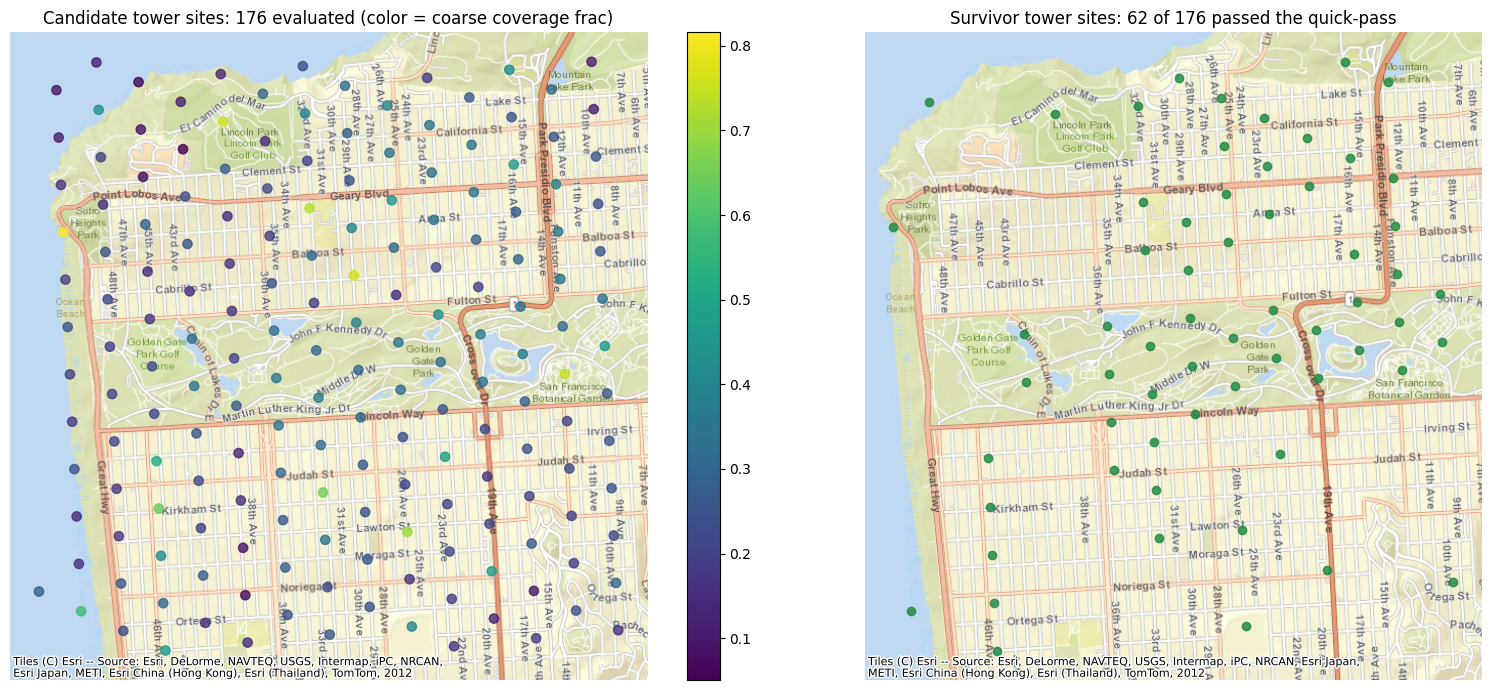

In [0]:
# Candidate (A) and survivor (B) tower sites, side by side.
import geopandas as _gpd
import matplotlib.pyplot as _plt
from shapely.geometry import Point as _Pt

def _pts_gdf(latlng):
    return _gpd.GeoDataFrame(geometry=[_Pt(lo, la) for (la, lo) in latlng], crs="EPSG:4326")

_scope = "" if DEMO else " across SF"
_ms = 45 if DEMO else 18
_figAB, (_axA, _axB) = _plt.subplots(1, 2, figsize=(16, 7))
# A — every candidate centroid, colored by its coarse quick-pass coverage.
plot_static(_points_as_gdf(quick, "lon", "lat", value_cols=("quick_frac",)),
            column="quick_frac", cmap="viridis", markersize=_ms, ax=_axA,
            title=f"Candidate tower sites{_scope}: {_n_cand} evaluated (color = coarse coverage frac)")
# B — the survivors that cleared the quick-pass rule-out.
plot_static([vector_layer(_pts_gdf(survivors), geom_col="geometry", color="#238b45",
                          opacity=0.85, label="survivor")], ax=_axB,
            title=f"Survivor tower sites{_scope}: {len(survivors)} of {_n_cand} passed the quick-pass")
_figAB.tight_layout()

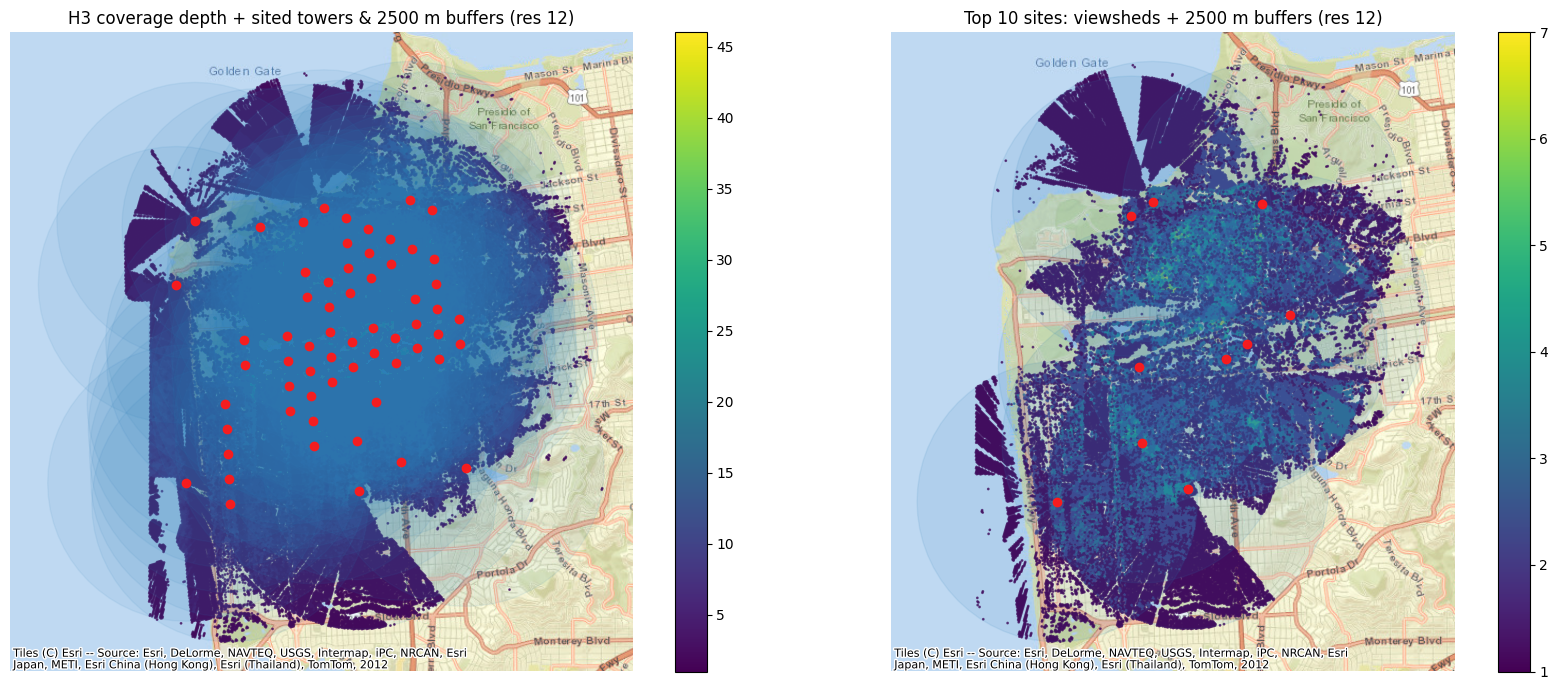

In [0]:
# Coverage depth: all sited towers (C) beside the top-10 by coverage (D).
if DEMO:
    import geopandas as _gpd
    import matplotlib.pyplot as _plt
    from shapely.geometry import Point as _Pt
    _figCD, (_axC, _axD) = _plt.subplots(1, 2, figsize=(17, 7))
    # C — per-cell coverage depth with all sited towers + their 2.5 km buffers overlaid.
    _sp = sites.select("lon", "lat").toPandas()
    _bufs = _gpd.GeoDataFrame(
        geometry=[_Pt(*lonlat_to_3857(lo, la)).buffer(MAX_DIST_M) for lo, la in zip(_sp.lon, _sp.lat)],
        crs="EPSG:3857").to_crs("EPSG:4326")
    plot_static([
        vector_layer(cells_as_gdf(cov.select("cellid", "tower_los_count"), "cellid",
                     extra_cols=("tower_los_count",), max_rows=200_000),
                     geom_col="geometry", column="tower_los_count", cmap="viridis",
                     opacity=0.7, label=f"towers w/ LOS (res {VIEWSHED_RES})"),
        vector_layer(_bufs, geom_col="geometry", color="#2c7fb8", opacity=0.08,
                     label=f"{MAX_DIST_M:.0f} m tower buffer"),
        vector_layer(_points_as_gdf(sites, "lon", "lat"), geom_col="geometry", color="#FF1A1A",
                     opacity=0.95, label="sited tower"),
    ], ax=_axC, title=f"H3 coverage depth + sited towers & {MAX_DIST_M:.0f} m buffers (res {VIEWSHED_RES})")
    # D — the 10 best sites (by coverage): their 2.5 km buffers and the cells they can see.
    _top = sites.orderBy(F.col("viewshed_cells").desc()).limit(10).select("lon", "lat").toPandas()
    _top_bufs = _gpd.GeoDataFrame(
        geometry=[_Pt(*lonlat_to_3857(lo, la)).buffer(MAX_DIST_M) for lo, la in zip(_top.lon, _top.lat)],
        crs="EPSG:3857").to_crs("EPSG:4326")
    plot_static([
        vector_layer(cells_as_gdf(cov_top10.select("cellid", "tower_los_count"), "cellid",
                     extra_cols=("tower_los_count",), max_rows=200_000),
                     geom_col="geometry", column="tower_los_count", cmap="viridis", opacity=0.7,
                     label="towers w/ LOS (top 10)"),
        vector_layer(_top_bufs, geom_col="geometry", color="#2c7fb8", opacity=0.1,
                     label=f"{MAX_DIST_M:.0f} m buffer"),
        vector_layer(_gpd.GeoDataFrame(geometry=[_Pt(lo, la) for lo, la in zip(_top.lon, _top.lat)],
                     crs="EPSG:4326"), geom_col="geometry", color="#FF1A1A", opacity=0.95,
                     label="top-10 tower"),
    ], ax=_axD, title=f"Top 10 sites: viewsheds + {MAX_DIST_M:.0f} m buffers (res {VIEWSHED_RES})")
    _figCD.tight_layout()
else:
    # Full San Francisco: res-12 coverage is too dense to map whole-SF, so show_cell_map
    # gives an SF overview + Golden Gate Park detail with the sited towers in red.
    _sites_gdf = _points_as_gdf(spark.table(_tbl(OUT_PREFIX, "candidate_sites", TOWER_RES)), "lon", "lat")
    show_cell_map(spark.table(_tbl(OUT_PREFIX, "coverage", VIEWSHED_RES)), "tower_los_count",
                  "H3 coverage depth (sited towers in red) - towers with line-of-sight per cell",
                  cmap="viridis", markers=_sites_gdf)

## Summary

A **naive** H3-native tower siting pass: candidate towers on the cell lattice, surface-level
line-of-sight computed as an exact search over H3 "pixels", and a cheap **quick-pass rule-out** so most
sites are discarded before the detailed viewshed. Each surviving site carries two honest factors —
**required mast** (`CHM` + antenna clearance) and **viewshed coverage** — left as separate columns for
you to trade off. Outputs: `wc_h3_quickpass` (every candidate's coarse score), `wc_h3_candidate_sites`
(ranked survivors), and `wc_h3_coverage` / `wc_h3_coverage_top10` (per-cell LOS depth).

**Next:** a `land_cover` notebook weights coverage by demand (people/buildings), excludes
water/park/no-build, and optimizes the best spot within each cell — turning this baseline into a
smarter siting tool.

## Table outputs

All tables this series wrote land in `geospatial_docs.geobrix` (your `CATALOG.SCHEMA`). The docs
[Table catalog](https://databrickslabs.github.io/geobrix/docs/notebooks/wireless-coverage?flavor=notebooks#table-catalog)
describes each one (and marks which are shared with the Lakeflow flavor). `SHOW TABLES` lists them:


In [0]:
# What this series wrote (full names carry _demo for a DEMO run, _res<n> for H3 tables).
spark.sql(f"SHOW TABLES IN {CATALOG}.{SCHEMA}").show(100, truncate=False)


+--------+-------------------------------+-----------+
|database|tableName                      |isTemporary|
+--------+-------------------------------+-----------+
|geobrix |bench_results                  |false      |
|geobrix |geomk_bench                    |false      |
|geobrix |overture_buildings_meta        |false      |
|geobrix |sf_building_shards             |false      |
|geobrix |sf_buildings_mvt_shards_src    |false      |
|geobrix |sf_buildings_mvt_tiles         |false      |
|geobrix |sf_cog_catalog                 |false      |
|geobrix |sf_hillshade_xyz_tiles         |false      |
|geobrix |sf_naip_xyz_tiles              |false      |
|geobrix |sf_solar_cells                 |false      |
|geobrix |sf_terrain                     |false      |
|geobrix |wc_h3_candidate_sites_demo_res9|false      |
|geobrix |wc_h3_candidate_sites_res9     |false      |
|geobrix |wc_h3_chm_demo_res10           |false      |
|geobrix |wc_h3_chm_res10                |false      |
|geobrix |

## Next — [Coming Soon]

A `land_cover` notebook weights coverage by demand (people/buildings), excludes water/park/no-build,
and optimizes the best spot within each cell — turning this baseline into a smarter siting tool.
